# ResOSc — New Features Demo

This notebook demonstrates the three additions to the ResOSc package:

1. **Force-model selection** — strain (GW), uniform momentum-impulse (DM), and custom spatial profiles via `compute_forces(force_model=...)`.
2. **Non-interacting reference system & frequency-spread analysis** via `reference_system()` and `frequency_spread()`.
3. **Sensitivity normalisation** against the uncoupled minimax benchmark via `normalized_sensitivity_profile()` and the `reference` argument to `compare_observables()`.

The original package demo (`ResOSc_demo.ipynb`) is unchanged.

## Imports

In [45]:
import numpy as np
import matplotlib.pyplot as plt

from ResOSc import CoupledSystem                                    # type: ignore
from ResOSc.plotting import setup_plot_style                        # type: ignore
from ResOSc.observables import (                                    # type: ignore
    coupling_heatmap, find_minimum_observables,
    optimize_observable, compare_observables,
    normalized_sensitivity_profile,
)

## System Setup

We reuse the same 10-oscillator system from the original demo so results are directly comparable.

In [46]:
sys = CoupledSystem(n=10)
# Individual masses — irregular, not proportional to wall springs
sys.set_masses([1.0, 0.5, 1.5, 0.7, 1.2, 0.4, 1.8, 0.6, 1.4, 0.8])

# Spring constants: wall springs (k_ii) and coupling springs (k_{i,i+1})
# k_ii varies widely and is NOT proportional to mass, so k_ii/m_i differs
# greatly across the chain.  This breaks the near-degenerate cosine-mode
# structure and makes the GW (strain, f_i ~ k_ii) and DM (uniform) force
# profiles clearly distinct.
sys.set_springs(
    wall=[2.0, 0.3, 2.5, 0.4, 1.8, 2.2, 0.5, 1.6, 0.6, 2.4],   # len = n
    coupling=[0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4],     # len = n - 1
)

sys.set_damping(gamma=0.01)
sys.solve()

L  = 1.0   # apparatus length
h0 = 1.0   # signal amplitude

import os
save_plots = 'figures-new'

def fig_path(name):
    if save_plots is None:
        return None
    os.makedirs(save_plots, exist_ok=True)
    return os.path.join(save_plots, name)

setup_plot_style()
print(f'Normal frequencies: {np.array2string(sys.frequencies, precision=4)}')


Normal frequencies: [2.7558 2.0271 1.8838 1.7389 1.5891 1.4867 1.2686 1.1189 0.9462 0.7968]


---
# 1. Force-Model Selection

`compute_forces()` now accepts a `force_model` keyword:

| Model | Force on oscillator $i$ | Physical scenario |
|---|---|---|
| `'strain'` *(default)* | $f_i = h_0 L \, k_{ii}$ | GW tidal force — proportional to local wall-spring stiffness |
| `'uniform'` | $f_i = h_0 L$ | Dark-matter momentum impulse — identical kick on every mass |
| `'custom'` | $f_i = h_0 \, v_i$ | Coherent DM wave, position-dependent coupling, etc. |

The physically important quantity is the **generalized force** $q_\alpha = \sum_j A_{\alpha j} f_j$ projected onto each normal mode.

**Key qualitative difference:** for a symmetric array driven *uniformly*, antisymmetric modes satisfy $\sum_j A_{\alpha j} \approx 0$, so the DM impulse concentrates signal in the centre-of-mass-like mode and leaves antisymmetric modes nearly undriven — the opposite of the GW case where stiffer oscillators are driven harder.

In [47]:
# Oscillator positions along the chain (unit spacing)
positions = np.arange(sys.n, dtype=float)

# ── 1a. Strain (GW) ───────────────────────────────────────────────────────
sys.compute_forces(L=L, h0=h0, force_model='strain')
q_strain     = sys.q.copy()
peaks_strain = sys.peak_sensitivities()

# ── 1b. Uniform momentum impulse (DM) ────────────────────────────────────
sys.compute_forces(L=L, h0=h0, force_model='uniform')
q_uniform     = sys.q.copy()
peaks_uniform = sys.peak_sensitivities()

# ── 1c. Coherent DM wave: f_i = h0 * L * cos(k_DM * x_i) ────────────────
# k_DM = pi/(n+1) ensures no oscillator sits exactly at a force node
# (i.e. cos(k_DM * x_i) != 0 for all i), which keeps the reference
# sensitivities well-defined for the normalisation in Section 3.
k_DM          = np.pi / (sys.n + 1)
force_profile = L * np.cos(k_DM * positions)
sys.compute_forces(h0=h0, force_model='custom', force_vec=force_profile)
q_custom     = sys.q.copy()
peaks_custom = sys.peak_sensitivities()

# ── Print table ───────────────────────────────────────────────────────────
print(f"{'Mode':<6} {'omega*':>8} {'q (strain)':>12} {'q (uniform)':>13} {'q (coherent)':>14}")
print('─' * 57)
for i in range(sys.n):
    print(f"{i:<6} {sys.frequencies[i]:>8.4f}"
          f" {q_strain[i]:>12.4f} {q_uniform[i]:>13.4f} {q_custom[i]:>14.4f}")

Mode     omega*   q (strain)   q (uniform)   q (coherent)
─────────────────────────────────────────────────────────
0        2.7558      -1.7602       -0.6676        -0.0865
1        2.0271      -1.5337       -0.6449         0.3113
2        1.8838       2.1133        0.7406        -0.6793
3        1.7389       2.6638        0.6640         0.5887
4        1.5891      -1.4809       -0.3616        -0.0771
5        1.4867      -0.5423       -0.4490        -0.1896
6        1.2686       1.2375        0.6670         0.9428
7        1.1189       2.8801        2.0168         1.4668
8        0.9462      -0.7922       -0.8881         0.7274
9        0.7968       0.8874        1.3151        -0.2717


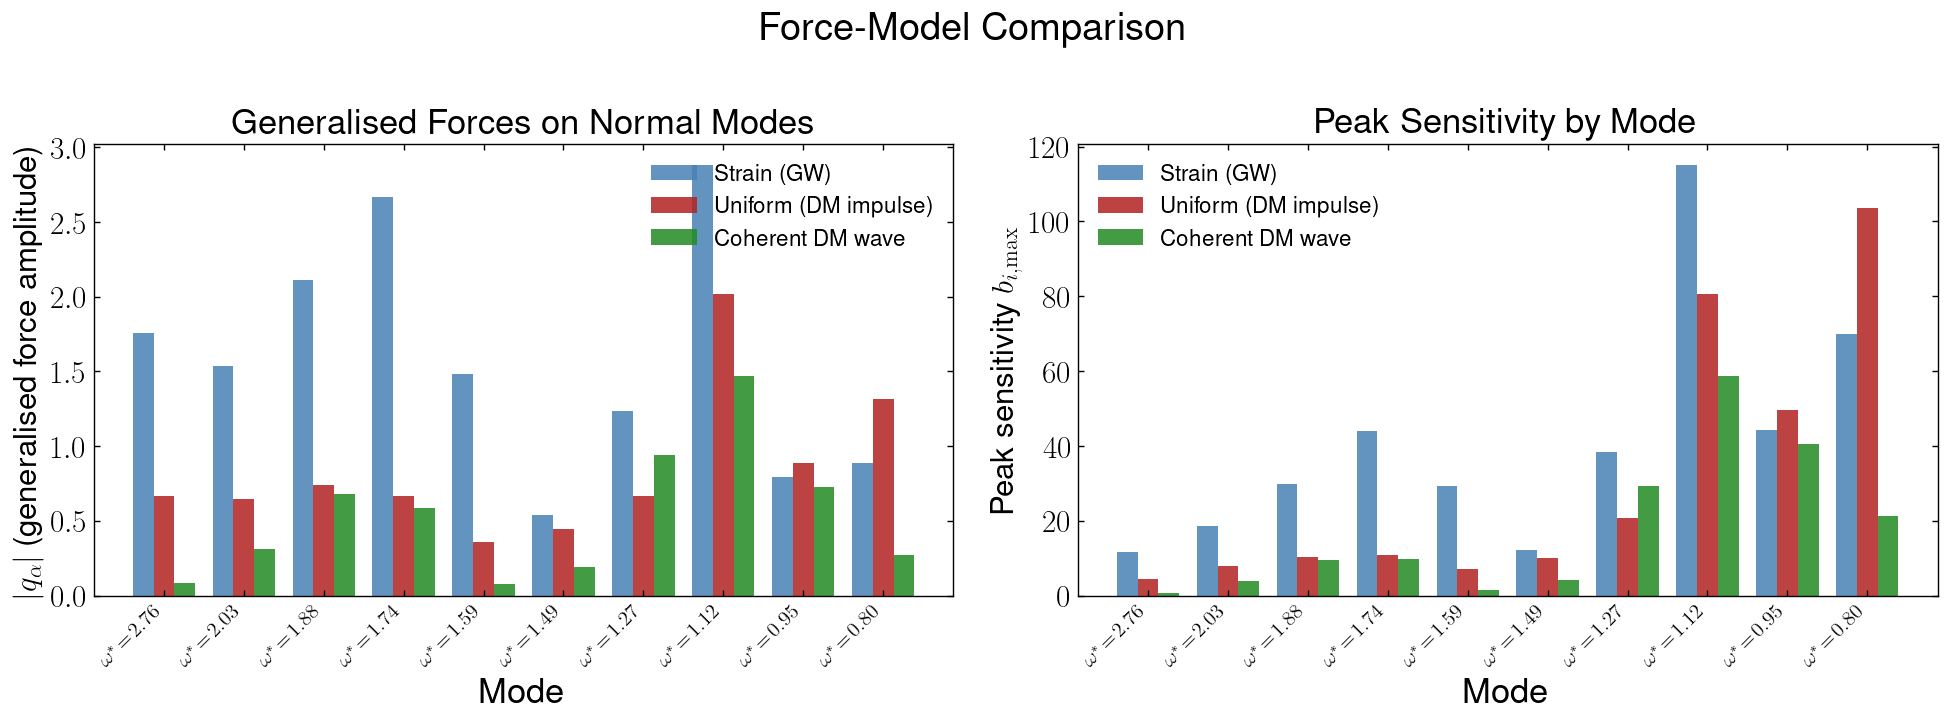

array([-1.7601668 , -1.53366172,  2.1132871 ,  2.66384571, -1.48092774,
       -0.54231608,  1.23754822,  2.88009456, -0.79223403,  0.88735212])

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=125)
x_pos  = np.arange(sys.n)
w      = 0.26
colors = ['steelblue', 'firebrick', 'forestgreen']
labels = ['Strain (GW)', 'Uniform (DM impulse)', 'Coherent DM wave']

# Left panel — |q_alpha|
for k, (q, col, lab) in enumerate(zip([q_strain, q_uniform, q_custom], colors, labels)):
    axes[0].bar(x_pos + (k - 1) * w, np.abs(q), w, label=lab, color=col, alpha=0.85)
axes[0].set_xlabel(r'Mode', fontsize=20)
axes[0].set_ylabel(r'$|q_\alpha|$  (generalised force amplitude)', fontsize=18)
axes[0].set_title(r'Generalised Forces on Normal Modes', fontsize=20)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([fr'$\omega^*\!=\!{sys.frequencies[i]:.2f}$' for i in range(sys.n)],
                         rotation=45, ha='right', fontsize=12)
axes[0].legend(frameon=False, fontsize=13)
axes[0].tick_params(direction='in', top=True, right=True)

# Right panel — peak sensitivity b_{i,max}
for k, (p, col, lab) in enumerate(zip([peaks_strain, peaks_uniform, peaks_custom], colors, labels)):
    axes[1].bar(x_pos + (k - 1) * w, p, w, label=lab, color=col, alpha=0.85)
axes[1].set_xlabel(r'Mode', fontsize=20)
axes[1].set_ylabel(r'Peak sensitivity $b_{i,\max}$', fontsize=18)
axes[1].set_title(r'Peak Sensitivity by Mode', fontsize=20)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([fr'$\omega^*\!=\!{sys.frequencies[i]:.2f}$' for i in range(sys.n)],
                         rotation=45, ha='right', fontsize=12)
axes[1].legend(frameon=False, fontsize=13)
axes[1].tick_params(direction='in', top=True, right=True)

plt.suptitle(r'Force-Model Comparison', fontsize=22)
plt.tight_layout()
if save_plots:
    fig.savefig(fig_path('force_model_comparison.pdf'), format='pdf',
                bbox_inches='tight', pad_inches=0.10)
plt.show()

# Restore strain model so subsequent cells are in a clean state
sys.compute_forces(L=L, h0=h0, force_model='strain')

## 1b. Stem Plots: Force Profiles and Generalised Forces

Two questions answered visually for each force model:

1. **What does the force look like in space?** — top row: $f_j$ vs oscillator index $j$.
2. **What does the force project onto each normal mode?** — bottom row: $q_\alpha$ vs mode index $\alpha$, where $q_\alpha = \sum_j A_{\alpha j} f_j$.

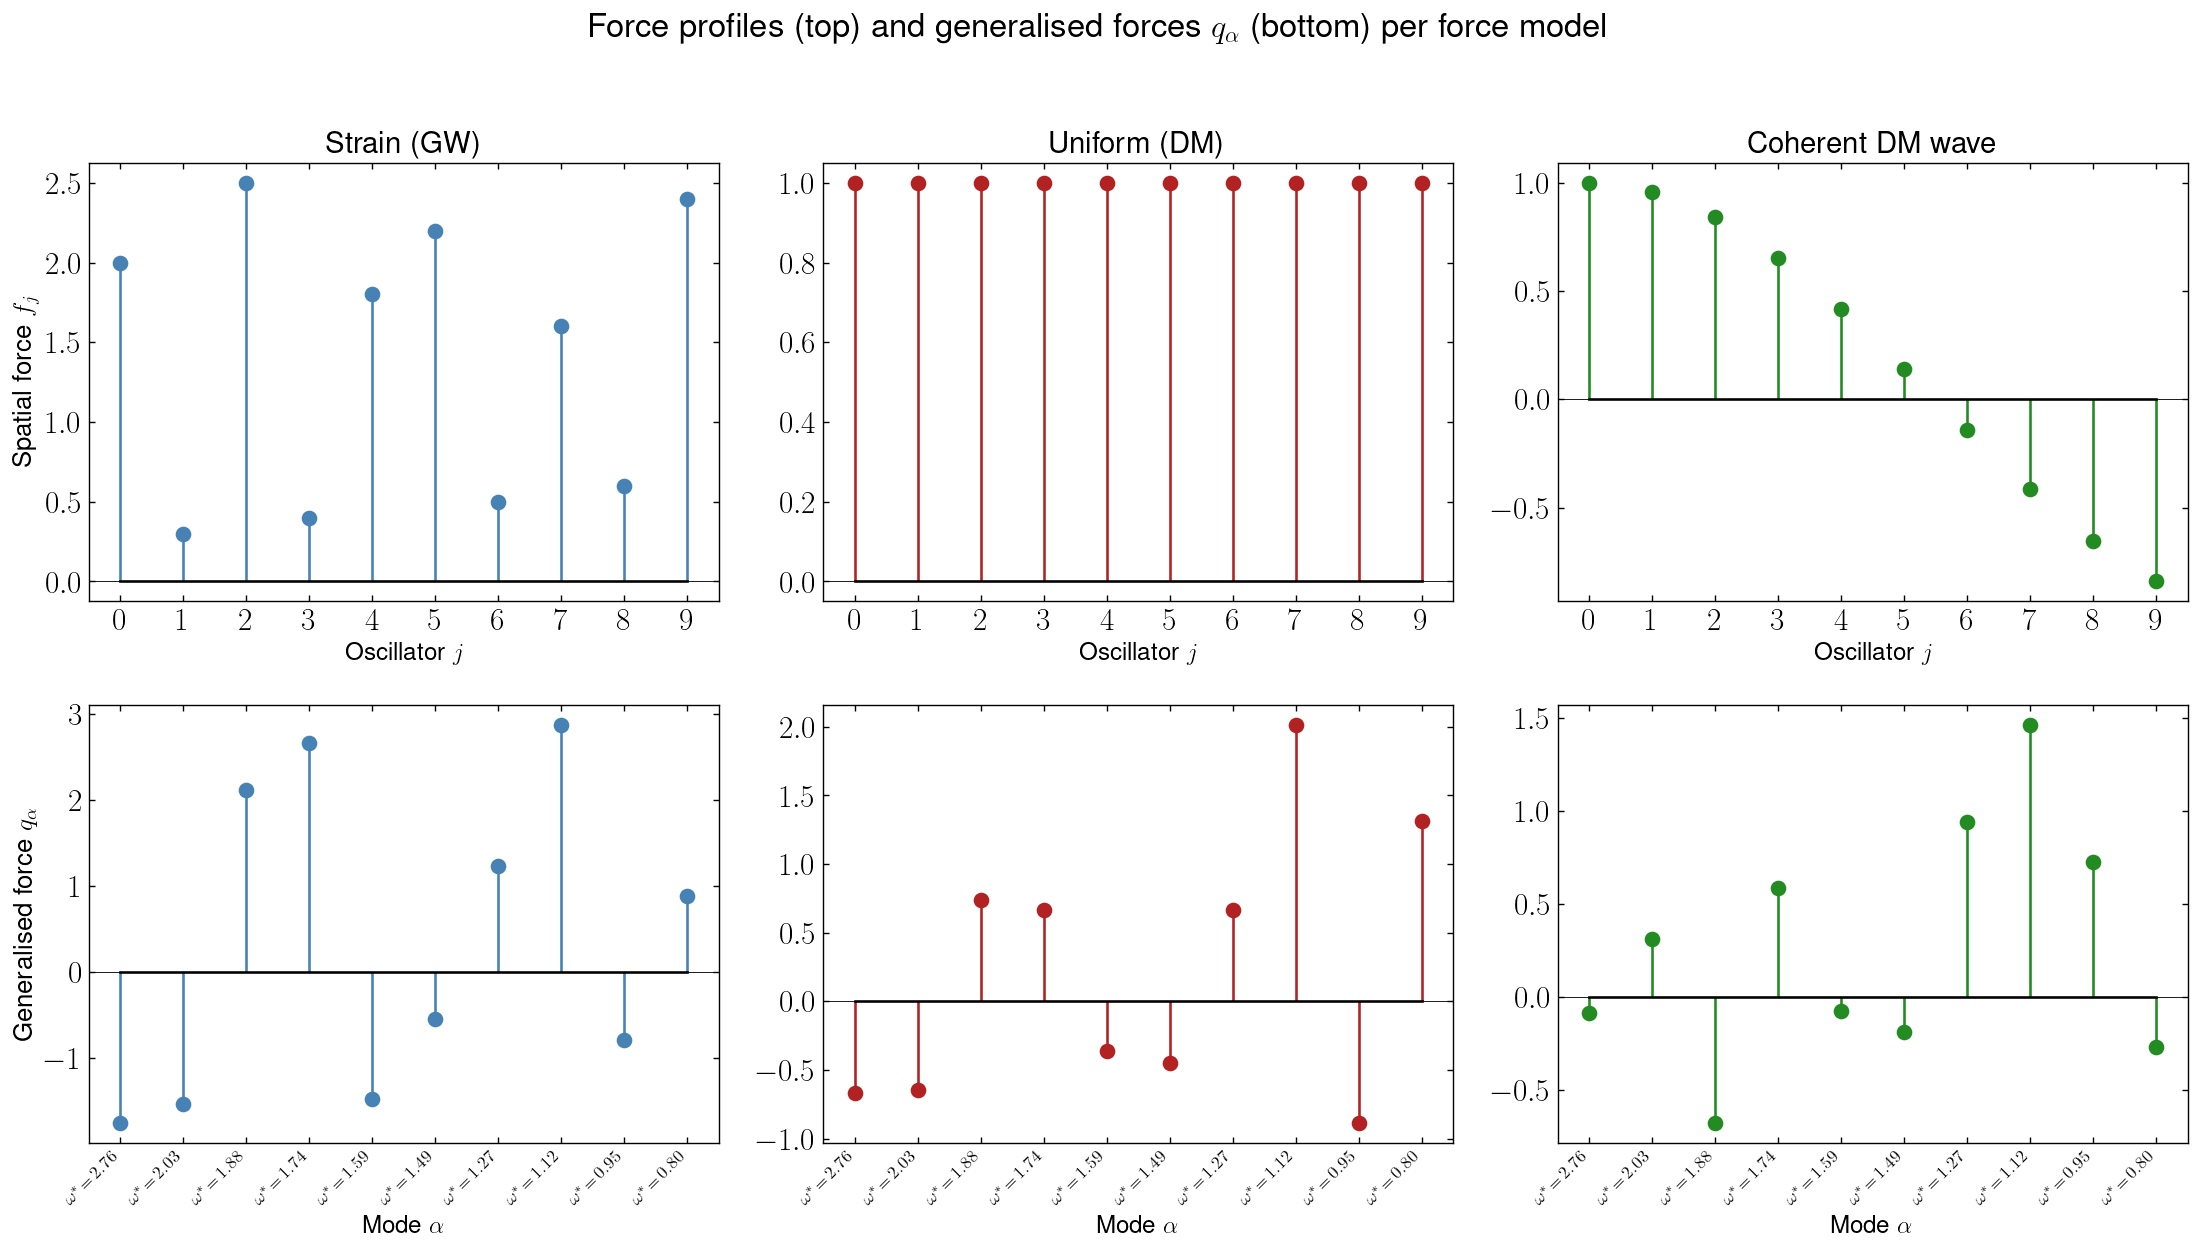

array([-1.7601668 , -1.53366172,  2.1132871 ,  2.66384571, -1.48092774,
       -0.54231608,  1.23754822,  2.88009456, -0.79223403,  0.88735212])

In [49]:
osc_idx  = np.arange(sys.n)
mode_idx = np.arange(sys.n)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=125)

# Re-collect spatial force vectors for all three models
positions     = np.arange(sys.n, dtype=float)
k_DM          = np.pi / (sys.n + 1)
force_profile = L * np.cos(k_DM * positions)

sys.compute_forces(L=L, h0=h0, force_model='strain')
f_strain,  q_strain  = sys.f.copy(), sys.q.copy()

sys.compute_forces(L=L, h0=h0, force_model='uniform')
f_uniform, q_uniform = sys.f.copy(), sys.q.copy()

sys.compute_forces(h0=h0, force_model='custom', force_vec=force_profile)
f_custom,  q_custom  = sys.f.copy(), sys.q.copy()

models = [
    ('Strain (GW)',       f_strain,  q_strain,  'steelblue'),
    ('Uniform (DM)',      f_uniform, q_uniform, 'firebrick'),
    ('Coherent DM wave',  f_custom,  q_custom,  'forestgreen'),
]

for col, (title, f_vec, q_vec, color) in enumerate(models):

    # ── Row 0: spatial force profile ─────────────────────────────────────
    ax = axes[0, col]
    ml, sl, _ = ax.stem(osc_idx, f_vec, linefmt='-', markerfmt='o', basefmt='k-')
    sl.set_color(color); ml.set_color(color); ml.set_markersize(8)
    ax.set_title(title, fontsize=17)
    ax.set_xlabel(r'Oscillator $j$', fontsize=14)
    if col == 0:
        ax.set_ylabel(r'Spatial force  $f_j$', fontsize=15)
    ax.set_xticks(osc_idx)
    ax.tick_params(direction='in', top=True, right=True)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlim(-0.5, sys.n - 0.5)

    # ── Row 1: generalised forces q_alpha ────────────────────────────────
    ax = axes[1, col]
    ml, sl, _ = ax.stem(mode_idx, q_vec, linefmt='-', markerfmt='o', basefmt='k-')
    sl.set_color(color); ml.set_color(color); ml.set_markersize(8)
    ax.set_xlabel(r'Mode $\alpha$', fontsize=14)
    if col == 0:
        ax.set_ylabel(r'Generalised force  $q_\alpha$', fontsize=15)
    ax.set_xticks(mode_idx)
    ax.set_xticklabels(
        [fr'$\omega^*\!=\!{sys.frequencies[i]:.2f}$' for i in range(sys.n)],
        rotation=45, ha='right', fontsize=10)
    ax.tick_params(direction='in', top=True, right=True)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlim(-0.5, sys.n - 0.5)

fig.suptitle(r'Force profiles (top) and generalised forces $q_\alpha$ (bottom) per force model',
             fontsize=19, y=1.01)
plt.tight_layout()
if save_plots:
    fig.savefig(fig_path('force_profiles_and_q.pdf'), format='pdf',
                bbox_inches='tight', pad_inches=0.10)
plt.show()

# Restore strain model as default state for subsequent cells
sys.compute_forces(L=L, h0=h0, force_model='strain')

## 1b. Contribution Heatmap: How $q_\alpha$ is Built

The generalised force $q_\alpha = \sum_j A_{\alpha j}\, f_j$ is a dot product — mode shape row times force column.  The heatmap below decomposes this sum: cell $(\alpha, j)$ is coloured by $A_{\alpha j} f_j$, so **the row sum of each row equals $q_\alpha$**.

Reading the heatmap tells you: *which oscillators drive which modes, and by how much?*

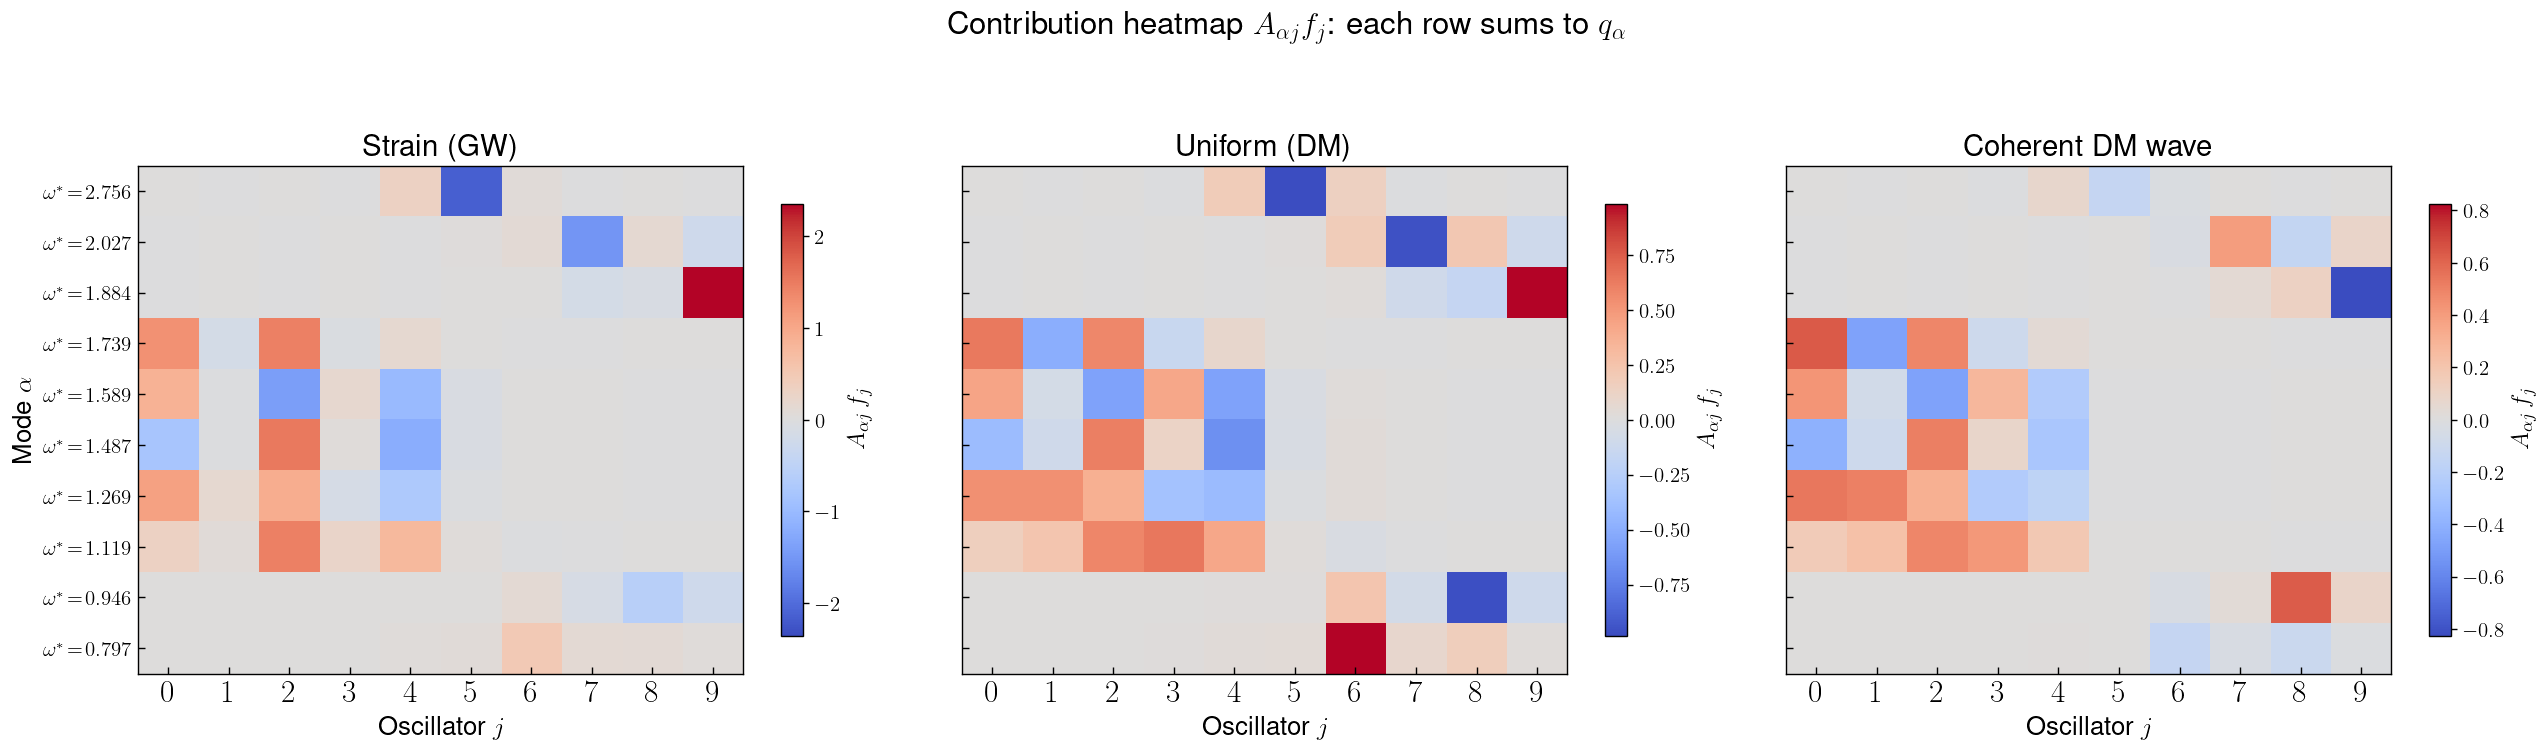

In [50]:
A = sys.eigenvectors   # rows = modes, cols = oscillators; available from sys.solve() above

# Re-collect spatial force vectors for all three models
positions     = np.arange(sys.n, dtype=float)
k_DM          = np.pi / (sys.n + 1)
force_profile = L * np.cos(k_DM * positions)

sys.compute_forces(L=L, h0=h0, force_model='strain')
f_strain,  q_strain  = sys.f.copy(), sys.q.copy()

sys.compute_forces(L=L, h0=h0, force_model='uniform')
f_uniform, q_uniform = sys.f.copy(), sys.q.copy()

sys.compute_forces(h0=h0, force_model='custom', force_vec=force_profile)
f_custom,  q_custom  = sys.f.copy(), sys.q.copy()

models = [
    ('Strain (GW)',       f_strain,  q_strain,  'steelblue'),
    ('Uniform (DM)',      f_uniform, q_uniform, 'firebrick'),
    ('Coherent DM wave',  f_custom,  q_custom,  'forestgreen'),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 6), dpi=125)

for ax, (title, f_vec, q_vec, _) in zip(axes, models):
    C    = A * f_vec[np.newaxis, :]          # C[alpha, j] = A[alpha,j] * f_j
    vmax = np.max(np.abs(C))
    im   = ax.imshow(C, cmap='coolwarm', aspect='auto', vmin=-vmax, vmax=vmax)

    ax.set_title(title, fontsize=17)
    ax.set_xlabel(r'Oscillator $j$', fontsize=15)
    ax.set_xticks(np.arange(sys.n))
    ax.set_yticks(np.arange(sys.n))
    if ax is axes[0]:
        ax.set_ylabel(r'Mode $\alpha$', fontsize=15)
        ax.set_yticklabels(
            [fr'$\omega^*\!=\!{sys.frequencies[i]:.3f}$' for i in range(sys.n)],
            fontsize=12)
    else:
        ax.set_yticklabels([])
    ax.tick_params(direction='in', length=4)

    cbar = fig.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label(r'$A_{\alpha j}\,f_j$', fontsize=14)
    cbar.ax.tick_params(labelsize=12)

fig.suptitle(
    r'Contribution heatmap $A_{\alpha j}f_j$: each row sums to $q_\alpha$',
    fontsize=18, y=1.02)
plt.tight_layout()
if save_plots:
    fig.savefig(fig_path('generalized_force_heatmap.pdf'), format='pdf',
                bbox_inches='tight', pad_inches=0.10)
plt.show()

### Why do the stem plots and heatmaps look like this?

**Force profiles (top row)**

- *Strain (GW)*: $f_j = h_0 L\, k_{jj}$.  Because every wall spring has the same stiffness $k_{jj} = 1.2$ in this system, the profile is perfectly flat — identical in shape to the uniform model, only rescaled by $1.2$.  In an array with varying wall springs the two profiles would diverge.
- *Uniform (DM impulse)*: $f_j = h_0 L$ — by construction a constant; the flattest possible drive.
- *Coherent DM wave*: $f_j = h_0 L\cos(k_\mathrm{DM} j)$ oscillates across the array.  $k_\mathrm{DM} = \pi/(n+1)$ places exactly half a wavelength over the chain, so $f$ has its maximum at oscillator 0 and smoothly approaches zero near oscillator $n/2$.

**Generalized forces (bottom row)**

$q_\alpha = \sum_j A_{\alpha j}\, f_j$ is an inner product between the mode shape and the force profile.

- *Strain/Uniform*: the flat drive weights every oscillator equally, so $q_\alpha \propto \sum_j A_{\alpha j}$.  Low-frequency modes (bottom rows of $A$) are more *in-phase* across the chain — their components add constructively — giving rising $|q_\alpha|$ toward the lowest mode.  The alternating signs come from the alternating parity of consecutive mode shapes.
- *Coherent DM wave*: the cosine profile selectively overlaps with modes whose spatial pattern matches $k_\mathrm{DM}$.  High-frequency modes (many nodes) suffer partial cancellation, so $|q_\alpha|$ drops sharply toward the top of the spectrum.  Sign changes reflect whether the dominant eigenvector lobes align or anti-align with the cosine.

**Contribution heatmaps** $A_{\alpha j}\, f_j$

Each cell shows how much oscillator $j$'s force contributes to driving mode $\alpha$.  The *row sum* of each row equals $q_\alpha$.

- For a flat force the heatmap is just the eigenvector matrix $A$ rescaled column-wise by a constant — you directly read off the mode shapes.
- For the coherent DM wave the columns are multiplied by $\cos(k_\mathrm{DM}\, j)$: oscillators near the point where the cosine crosses zero contribute little to any mode.  This is why high-frequency modes, whose eigenvector weight is concentrated in the middle of the chain, effectively disappear from $q_\alpha$.

---
# 2. Non-Interacting Reference System & Frequency Spread

## 2a. Reference System

`reference_system()` returns a solved copy of the system with all coupling springs set to zero.
Its eigenvector matrix is the identity. Each oscillator is its own normal mode with bare frequency

$$\omega_i^0 = \sqrt{k_{ii}/m_i}$$

This reference serves two purposes:
- **Frequency-spread baseline**: how much of the final bandwidth comes from varied wall springs vs. from coupling?
- **Sensitivity normalization**: what is the best sensitivity the uncoupled sensors can achieve? (Section 3.)

In [51]:
# Build and solve the non-interacting reference
ref = sys.reference_system()
ref.compute_forces(L=L, h0=h0, force_model='strain')

print('Non-interacting reference — bare oscillator frequencies:')
print(f'  {np.array2string(ref.frequencies, precision=4)}\n')
print('Coupled system — normal-mode frequencies:')
print(f'  {np.array2string(sys.frequencies, precision=4)}\n')
print('Coupling shifts and mixes the degenerate bare frequencies into the band above.')

Non-interacting reference — bare oscillator frequencies:
  [2.3452 1.7321 1.633  1.4142 1.291  1.2247 0.7746 0.7559 0.6547 0.527 ]

Coupled system — normal-mode frequencies:
  [2.7558 2.0271 1.8838 1.7389 1.5891 1.4867 1.2686 1.1189 0.9462 0.7968]

Coupling shifts and mixes the degenerate bare frequencies into the band above.


## 2b. Frequency-Spread Metrics

`frequency_spread(reference=ref)` returns a dict with:

| Key | Meaning |
|---|---|
| `'absolute'` | $\omega_{max} - \omega_{min}$: detector bandwidth (the physically relevant number) |
| `'relative'` | Absolute spread / geometric-mean frequency: dimensionless, comparable across systems |
| `'spacing_uniformity'` | CV of consecutive spacings: 0 = uniform grid, larger = clustered modes |
| `'absolute_gain'` | Extra bandwidth introduced by the coupling springs alone |
| `'relative_gain'` | Ratio of relative spreads (coupled / reference); $> 1$ means coupling widens the band |

**For a detector**, only the absolute spread of the final normal modes matters for bandwidth coverage.
The non-interacting spread is not directly observable once the system is coupled.
`absolute_gain` and `relative_gain` quantify how much of the bandwidth is *coupling-induced*,
which is useful for tuning: if the gain is large, adjusting coupling in situ is an efficient knob.

In [52]:
spread     = sys.frequency_spread(reference=ref)
ref_spread = ref.frequency_spread()

header = f"{'Metric':<28} {'Coupled':>10} {'Reference':>12}"
sep    = '─' * len(header)
rows = [
    ('Absolute spread',         spread['absolute'],           ref_spread['absolute']),
    ('Relative spread',         spread['relative'],           ref_spread['relative']),
    ('Spacing uniformity (CV)', spread['spacing_uniformity'], ref_spread['spacing_uniformity']),
    ('omega_min',               spread['omega_min'],          ref_spread['omega_min']),
    ('omega_max',               spread['omega_max'],          ref_spread['omega_max']),
]
print(header); print(sep)
for label, v_c, v_r in rows:
    v_r_str = f'{v_r:>12.4f}' if np.isfinite(v_r) else f"{'—':>12}"
    print(f'{label:<28} {v_c:>10.4f} {v_r_str}')
print(sep)
print(f'\n  Absolute gain from coupling : {spread["absolute_gain"]:+.4f}')
rg = spread.get('relative_gain', float('nan'))
if np.isfinite(rg):
    print(f'  Relative bandwidth ratio    : {rg:.4f}x')
else:
    print('  Relative bandwidth ratio    : — (reference spread is zero; all wall springs equal)')

Metric                          Coupled    Reference
────────────────────────────────────────────────────
Absolute spread                  1.9589       1.8182
Relative spread                  1.3350       1.6292
Spacing uniformity (CV)          0.8404       0.9267
omega_min                        0.7968       0.5270
omega_max                        2.7558       2.3452
────────────────────────────────────────────────────

  Absolute gain from coupling : +0.1408
  Relative bandwidth ratio    : 0.8194x


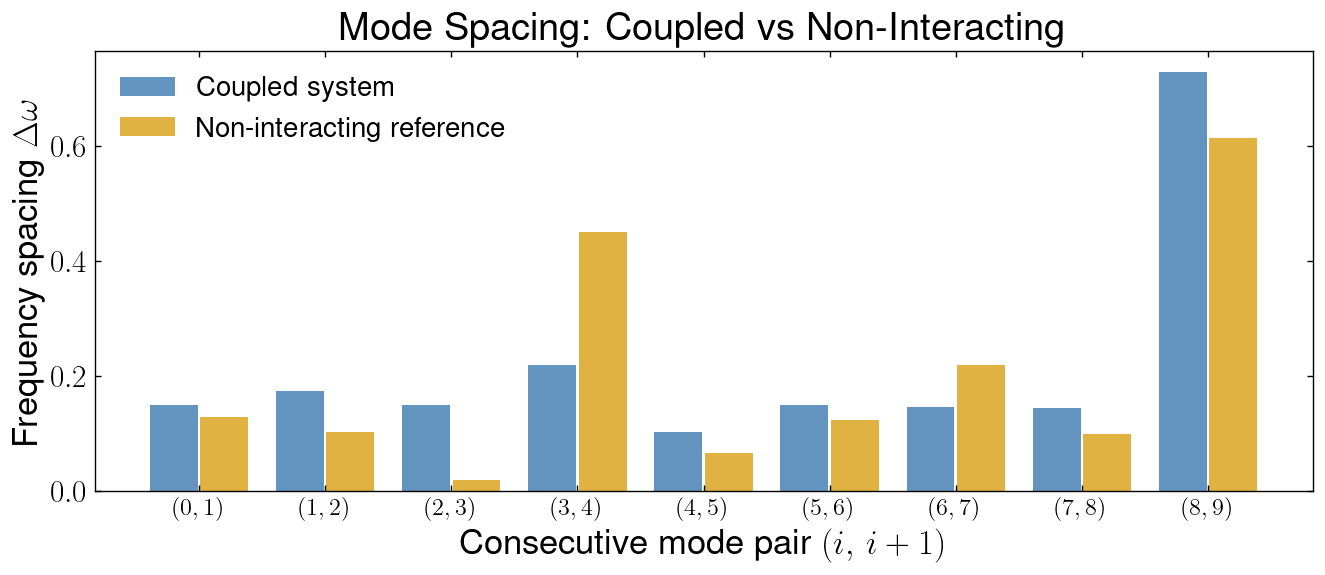

In [53]:
fig, ax = plt.subplots(figsize=(11, 5), dpi=125)
x_pos = np.arange(sys.n - 1)

ax.bar(x_pos - 0.2, spread['spacings'],     0.38,
       label=r'Coupled system',            color='steelblue', alpha=0.85)
ax.bar(x_pos + 0.2, ref_spread['spacings'], 0.38,
       label=r'Non-interacting reference', color='goldenrod', alpha=0.85)

ax.set_xlabel(r'Consecutive mode pair $(i,\,i+1)$', fontsize=20)
ax.set_ylabel(r'Frequency spacing $\Delta\omega$',   fontsize=20)
ax.set_title(r'Mode Spacing: Coupled vs Non-Interacting', fontsize=22)
ax.set_xticks(x_pos)
ax.set_xticklabels([fr'$({i},{i+1})$' for i in range(sys.n - 1)], fontsize=14)
ax.tick_params(direction='in', top=True, right=True)
ax.legend(frameon=False, fontsize=16)
plt.tight_layout()
if save_plots:
    fig.savefig(fig_path('frequency_spread.pdf'), format='pdf',
                bbox_inches='tight', pad_inches=0.10)
plt.show()

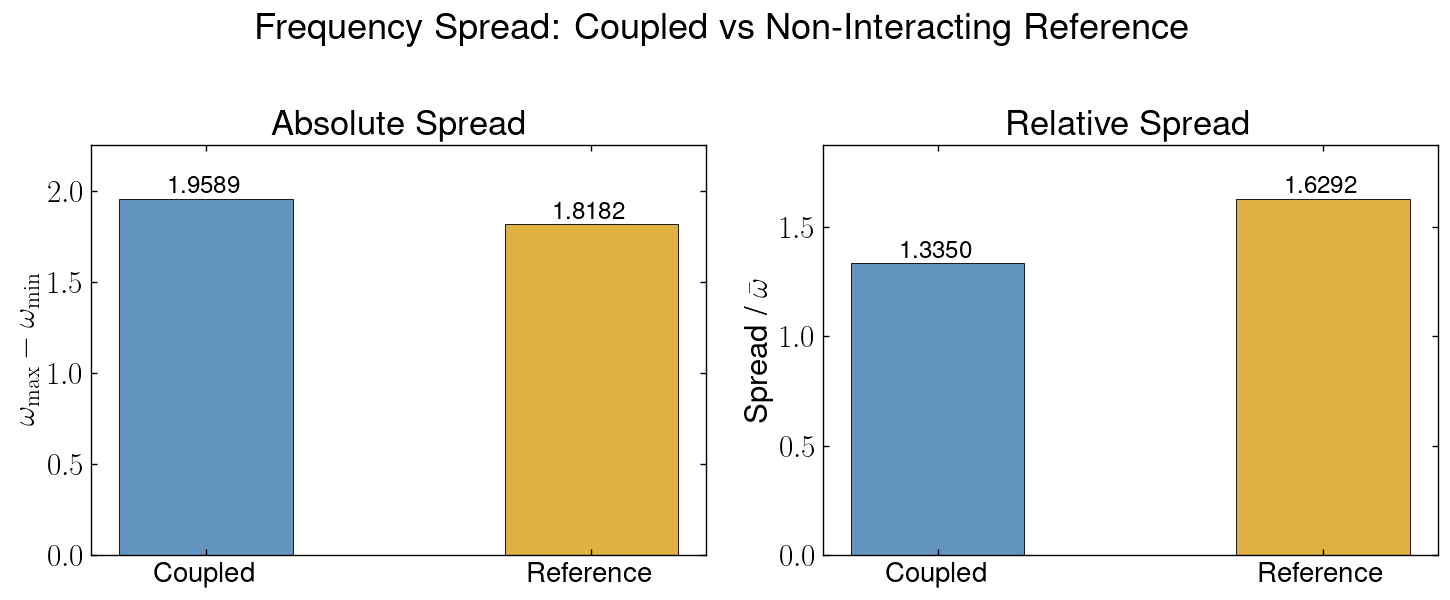

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=125)

labels  = ['Coupled', 'Reference']
colors  = ['steelblue', 'goldenrod']
x       = np.arange(len(labels))
w       = 0.45

# ── Left: absolute spread ────────────────────────────────────────────────
abs_vals = [spread['absolute'], ref_spread['absolute']]
bars = axes[0].bar(x, abs_vals, w, color=colors, alpha=0.85, edgecolor='k', linewidth=0.6)
for bar, val in zip(bars, abs_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=14)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=16)
axes[0].set_ylabel(r'$\omega_{\max} - \omega_{\min}$', fontsize=18)
axes[0].set_title(r'Absolute Spread', fontsize=20)
axes[0].tick_params(direction='in', top=True, right=True)
axes[0].set_ylim(0, max(abs_vals) * 1.15)

# ── Right: relative spread ───────────────────────────────────────────────
rel_vals = [spread['relative'], ref_spread['relative']]
bars = axes[1].bar(x, rel_vals, w, color=colors, alpha=0.85, edgecolor='k', linewidth=0.6)
for bar, val in zip(bars, rel_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=14)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=16)
axes[1].set_ylabel(r'Spread / $\bar\omega$', fontsize=18)
axes[1].set_title(r'Relative Spread', fontsize=20)
axes[1].tick_params(direction='in', top=True, right=True)
axes[1].set_ylim(0, max(rel_vals) * 1.15)

fig.suptitle(r'Frequency Spread: Coupled vs Non-Interacting Reference', fontsize=21)
plt.tight_layout()
if save_plots:
    fig.savefig(fig_path('frequency_spread_summary.pdf'), format='pdf',
                bbox_inches='tight', pad_inches=0.10)
plt.show()


---
# 3. Sensitivity Normalization Against the Reference

To judge whether coupling genuinely improves sensitivity, we compare against the
**minimax-optimal sensitivity of the non-interacting reference** — the best worst-case
sensitivity achievable with *any* linear combination of the uncoupled oscillator readouts:

$$\text{ref\_scale} = \frac{1}{\displaystyle\sqrt{\sum_i \dfrac{1}{b_{i,\text{ref}}^2}}}$$

For uniform reference sensitivities $b_\text{ref}$, this equals $b_\text{ref}/\sqrt{n}$.

Passing `reference=ref` to `compare_observables()`:
- Draws a gold dashed horizontal line at `ref_scale` on the plot.
- Adds `normalized_best_single_min` and `normalized_optimal_min_sensitivity` to the returned dict.

A normalized worst-case sensitivity $> 1$ means the coupled system outperforms the best uncoupled observable.

> **Note on the custom force model:** if any oscillator sits exactly at a force node ($f_i = 0$), its reference sensitivity is zero, and `ref_scale` is undefined ($\to 0$). This is avoided here by choosing $k_\mathrm{DM} = \pi/(n+1)$ so no position in the array is at a node.

## 3a. GW Strain Model

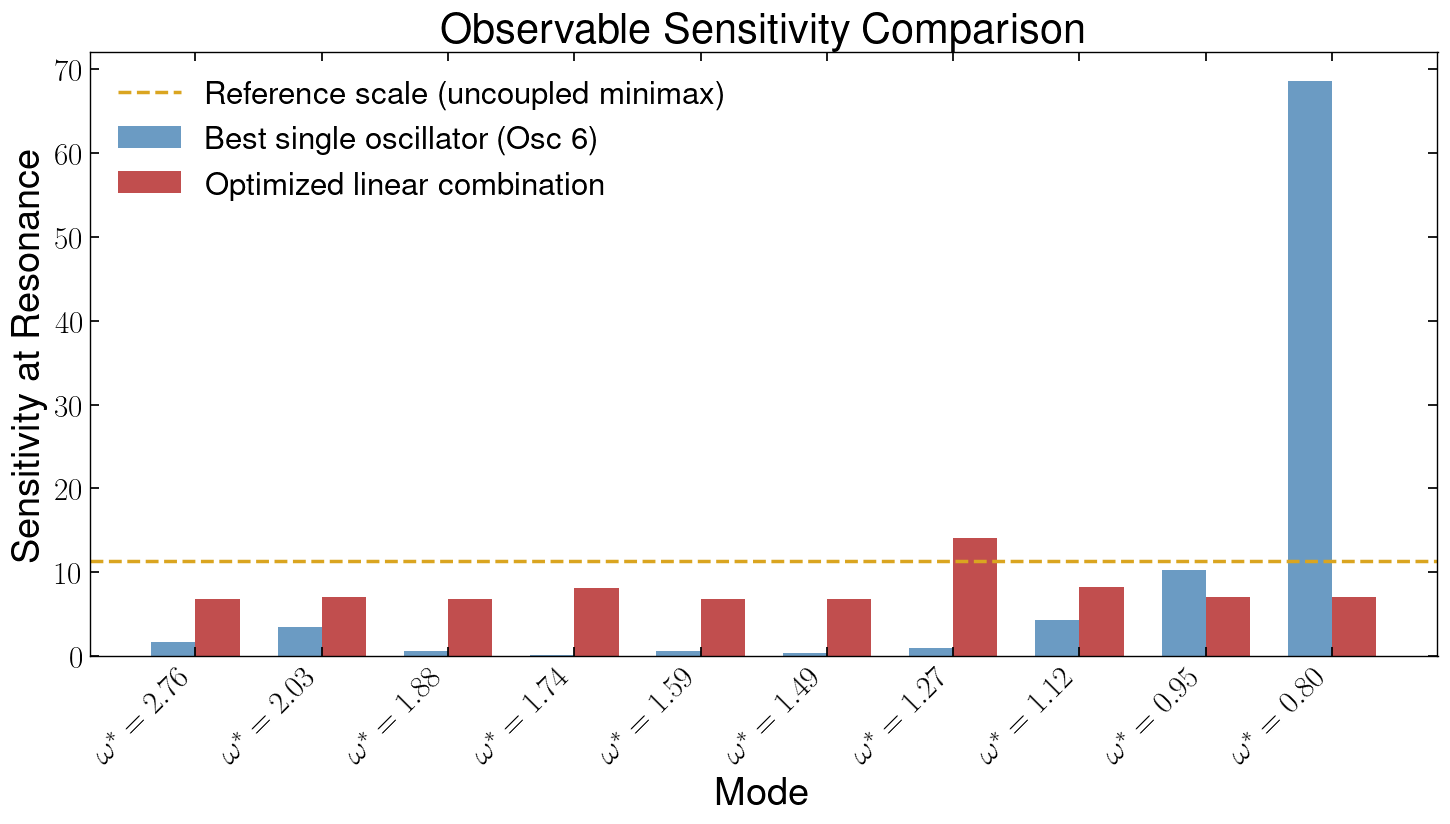

Reference scale (uncoupled minimax) : 11.2971

Best single oscillator (Osc 6):
  Worst-case sensitivity  : 0.1122
  Normalised              : 0.0099

Optimised linear combination:
  Worst-case sensitivity  : 6.8495
  Normalised              : 0.6063


In [55]:
sys.compute_forces(L=L, h0=h0, force_model='strain')
ref.compute_forces(L=L, h0=h0, force_model='strain')

comp_gw = compare_observables(sys, reference=ref,
                               savefig=fig_path('observable_comparison_gw.pdf'))

print(f"Reference scale (uncoupled minimax) : {comp_gw['ref_scale']:.4f}")
print(f"\nBest single oscillator (Osc {comp_gw['best_single_oscillator']}):")
print(f"  Worst-case sensitivity  : {np.min(comp_gw['best_single_sensitivities']):.4f}")
print(f"  Normalised              : {comp_gw['normalized_best_single_min']:.4f}")
print(f"\nOptimised linear combination:")
print(f"  Worst-case sensitivity  : {np.min(comp_gw['optimal_sensitivities']):.4f}")
print(f"  Normalised              : {comp_gw['normalized_optimal_min_sensitivity']:.4f}")

## 3b. DM Uniform Momentum Model

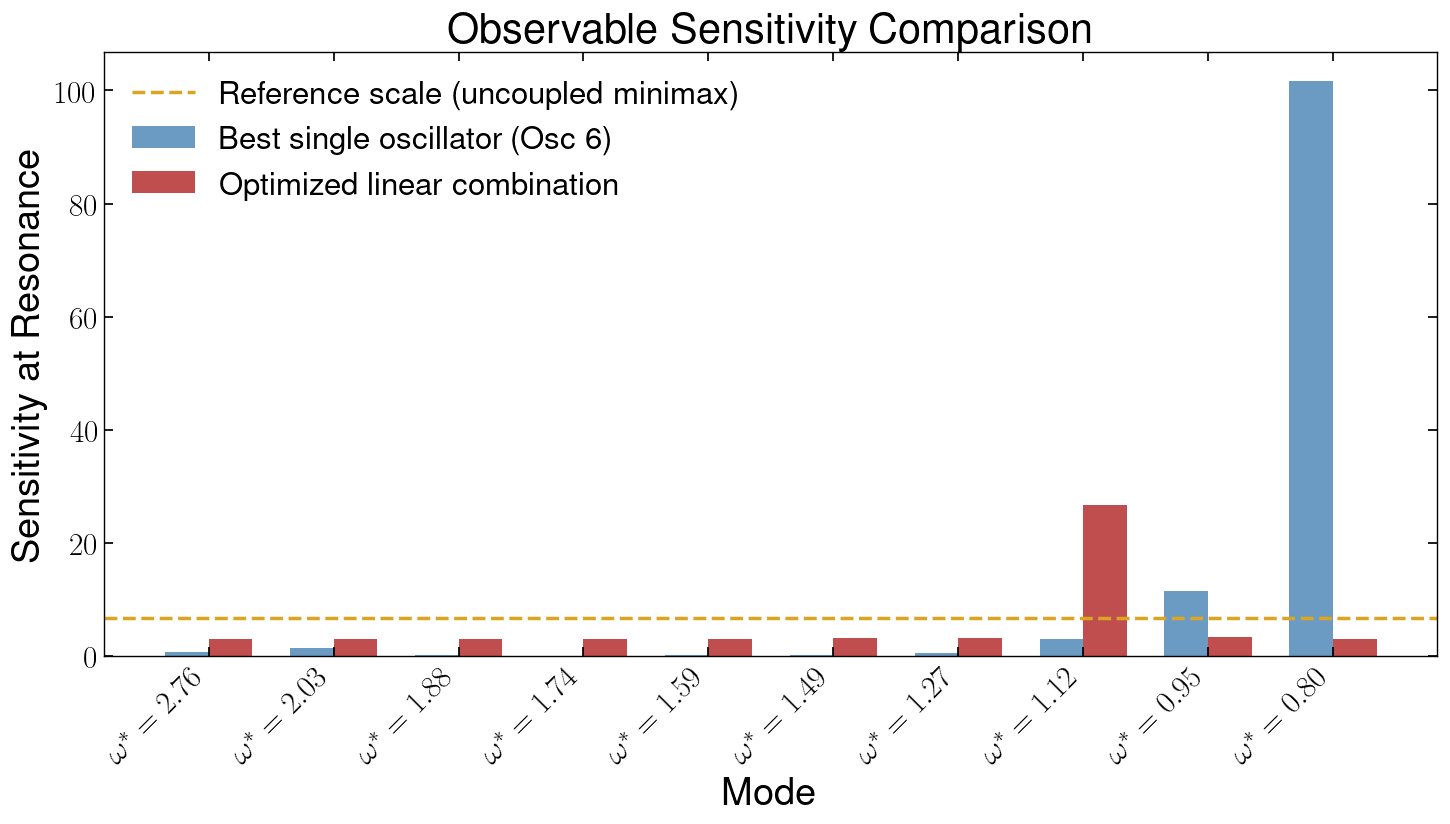

Reference scale (uncoupled minimax) : 6.6616

Best single oscillator (Osc 6):
  Worst-case sensitivity  : 0.0280
  Normalised              : 0.0042

Optimised linear combination:
  Worst-case sensitivity  : 2.9744
  Normalised              : 0.4465


In [56]:
sys.compute_forces(L=L, h0=h0, force_model='uniform')
ref.compute_forces(L=L, h0=h0, force_model='uniform')

comp_dm = compare_observables(sys, reference=ref,
                               savefig=fig_path('observable_comparison_dm.pdf'))

print(f"Reference scale (uncoupled minimax) : {comp_dm['ref_scale']:.4f}")
print(f"\nBest single oscillator (Osc {comp_dm['best_single_oscillator']}):")
print(f"  Worst-case sensitivity  : {np.min(comp_dm['best_single_sensitivities']):.4f}")
print(f"  Normalised              : {comp_dm['normalized_best_single_min']:.4f}")
print(f"\nOptimised linear combination:")
print(f"  Worst-case sensitivity  : {np.min(comp_dm['optimal_sensitivities']):.4f}")
print(f"  Normalised              : {comp_dm['normalized_optimal_min_sensitivity']:.4f}")

## 3c. Cross-Model Summary

The table below collects normalised minimax sensitivities for all three force models.

- **Below 1**: for the hardest-to-detect mode, coupling plus the optimised observable has not yet recovered the reference sensitivity.  The force model concentrates the signal in a subset of modes, leaving others weakly driven.
- **Above 1**: the coupled system with optimised weights beats the best any linear uncoupled observable can do.

In [57]:
# Coherent DM wave (k_DM = pi/(n+1), same as Section 1)
sys.compute_forces(h0=h0, force_model='custom', force_vec=force_profile)
ref.compute_forces(h0=h0, force_model='custom', force_vec=force_profile)
opt_coherent = optimize_observable(sys, reference=ref)

rows = [
    ('GW Strain',        comp_gw['normalized_optimal_min_sensitivity']),
    ('DM Uniform',       comp_dm['normalized_optimal_min_sensitivity']),
    ('DM Coherent wave', opt_coherent['normalized_min_sensitivity']),
]

print(f"\n{'Force model':<22} {'Normalised worst-case S':>24}")
print('─' * 52)
for label, val in rows:
    flag = '  > 1: coupling helps' if val > 1 else '  < 1: below reference'
    print(f"  {label:<20} {val:>20.4f}{flag}")
print('─' * 52)
print('\nAll values are relative to the uncoupled minimax reference scale.')

# Restore strain model as default state
sys.compute_forces(L=L, h0=h0, force_model='strain')


Force model             Normalised worst-case S
────────────────────────────────────────────────────
  GW Strain                          0.6063  < 1: below reference
  DM Uniform                         0.4465  < 1: below reference
  DM Coherent wave                   0.3998  < 1: below reference
────────────────────────────────────────────────────

All values are relative to the uncoupled minimax reference scale.


array([-1.7601668 , -1.53366172,  2.1132871 ,  2.66384571, -1.48092774,
       -0.54231608,  1.23754822,  2.88009456, -0.79223403,  0.88735212])